# Experimental validation of virtual *Osmr* overexpression
This tutorial examines the Willis BSAInf4 and OSMInf3 example using the red dorsal ROIs (Fig. 5L–N).
**Osmr** is raised to 2.62 in a random 50% of BSAInf4 ROI cells (seed 0); cells already above 2.62 are retained. Stage 2 is fitted for 100 epochs on the unmodified ROI pair and then frozen for virtual inference. Tokenization uses `hvg_log1p=True`.
The analyses show measured Osmr expression, the shift of non-OE neighbors within 150 µm toward the experimental OSM state, and pooled gene effects for 100 control-selected HVGs, excluding Osmr, using source-specific RMS normalization and asinh. All three analyses are recalculated here.

In [1]:
from pathlib import Path
import sys, os
ROOT = Path("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main")
TUTORIAL = ROOT / "tutorial"
FRAMEWORK = TUTORIAL / "_framework/BrainBeacon"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(FRAMEWORK))
from brainbeacon.configs.config import DEFAULT_PATHS
DEFAULT_PATHS.update({
    "BASE_DIR": str(ROOT), "PRIOR_DIR": str(ROOT / "prior_knowledge"),
    "PRETRAIN_DIR": str(ROOT / "pretrained"),
    "GENE_DICT_PATH": str(ROOT / "prior_knowledge/gene_dict.h5ad"),
    "GENE_LOOKUP_DIR": str(ROOT / "prior_knowledge/gene_lookup"),
    "ESM_EMBED_PATH": str(ROOT / "prior_knowledge/esm2_embeddings_d5120.pt"),
})

In [2]:
import gzip
import json
import os
import sys
import tarfile
import time
from pathlib import Path
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from scipy.io import mmread
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.spatial import cKDTree
BASE_DIR = Path('/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main')
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))
from brainbeacon.pipeline.cell_embedding import run_brainbeacon_pipeline
from brainbeacon.tokenizer import set_seed
from brainbeacon.pipeline.perturbation import apply_gene_perturbation, analyze_embedding_similarity_change, analyze_embedding_similarity_change_similarity_niche, plot_cosine_to_centroids_with_perturb, plot_spatial_delta_cosine_after_perturbation
from brainbeacon.pipeline.perturbation import analyze_gene_reconstruction_change, compute_public_perturbation_embedding_metrics

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset_name = 'willis_osm_xenium'
species = 'mouse'
assay = 'xenium'
GPU = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = GPU
set_seed(42)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}')
RAW_TAR = BASE_DIR / 'data' / 'perturb_data' / 'remyelination_niche_xenium_gse266689' / 'geo' / 'GSE266689_RAW.tar'
OUT_DIR = TUTORIAL / 'outputs/fig5_experimental_oe'
OUT_DIR.mkdir(parents=True, exist_ok=True)
gene_dict_path = BASE_DIR / 'prior_knowledge' / 'gene_dict.h5ad'
stage1_ckpt_path = BASE_DIR / 'prior_knowledge' / 'ABL1_full_final_epoch_0_step_10000.pt'
stage2_ckpt_path = BASE_DIR / 'prior_knowledge' / 'stage2_epoch280_fit200.pt'
stage1_config = {'dim_model': 1024, 'dim_feedforward': 1024, 'nheads': 16, 'nlayers': 16, 'n_connect_comp': 46714, 'use_esm_emb': True, 'use_gene_id_emb': True, 'use_homo_emb': True, 'use_rna_type_emb': True, 'use_gene_deviation': True, 'use_cell_density': True, 'use_dev_abs': True, 'esm_emb_dim': 5120, 'species': True, 'assay': True, 'n_hvg': 5000, 'use_hvg': True, 'weight_mode': 'expression', 'force_tokenize': True}
stage2_config = {'sampling_mode': 'spatial', 'use_patch': False, 'eval_use_patch': True}
TARGET_GENE_ID = 'ENSMUSG00000022146'
TARGET_SYMBOL = 'Osmr'
OE_TARGET_VALUE = 2.62
PERTURB_FRACTION = 0.5
PERTURB_RANDOM_STATE = 0
MIN_GENES = 3
BASELINE_FIT_EPOCHS = 100
RUN_BRAINBEACON = True
stage1_config.update(hvg_log1p=True, use_mean_norm=True, cd_weight=0.02)
stage2_config['pe_weight'] = 1.0
FIG_DIR = TUTORIAL / 'figures/fig5_experimental_oe'
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none', 'font.size': 10})

def save_panel(fig, stem):
    for extension in ('pdf', 'svg', 'png'):
        fig.savefig(FIG_DIR / f'{stem}.{extension}', dpi=300, bbox_inches='tight')
    plt.show()

Using device: cuda:0
Using GPU: NVIDIA H800


## 1. Inspect measured Osmr expression and the fixed red ROIs

In [4]:
INPUT_H5AD = ROOT / "downstream_tasks/public_perturb/willis_osm_final_adata/willis_osm_baseline_input_full_filtered.h5ad"
ROI_PATH = TUTORIAL / 'data/06_experimental_oe/dorsal_candidate_local.by_cell.csv.gz'
adata_panel = ad.read_h5ad(INPUT_H5AD, backed="r")
BSAInf_cells = adata_panel[adata_panel.obs["slice"].eq("GSM8647393_BSAInf4")].to_memory()
OSMInf_cells = adata_panel[adata_panel.obs["slice"].eq("GSM8647398_OSMInf3")].to_memory()
roi_df = pd.read_csv(ROI_PATH).set_index("obs_name")
def subset_red_roi(adata):
    flags = roi_df["dorsal_candidate_local"].reindex(adata.obs_names).fillna(False).astype(bool).to_numpy()
    sub = adata[flags].copy()
    for col in roi_df.columns:
        sub.obs[col] = roi_df[col].reindex(sub.obs_names).to_numpy()
    return sub
BSAInf_red_roi = subset_red_roi(BSAInf_cells)
OSMInf_red_roi = subset_red_roi(OSMInf_cells)
print("BSAInf4 / OSMInf3 ROI cells:", BSAInf_red_roi.n_obs, OSMInf_red_roi.n_obs)

BSAInf4 / OSMInf3 ROI cells: 902 2125


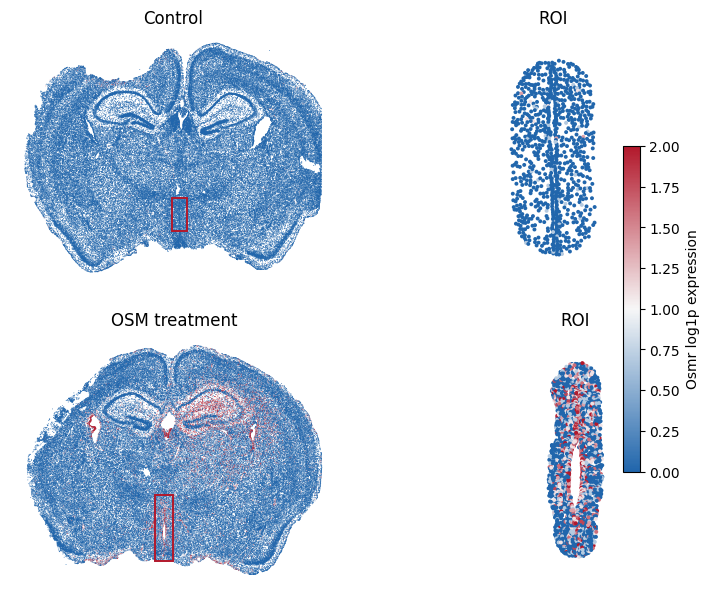

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8.4, 7.2), gridspec_kw={"width_ratios": [1.6, 1]})
cmap = LinearSegmentedColormap.from_list("Osmr_expression", ["#2166AC", "#F7F7F7", "#B2182B"])
for row, (full, roi, label) in enumerate([(BSAInf_cells, BSAInf_red_roi, "Control"), (OSMInf_cells, OSMInf_red_roi, "OSM treatment")]):
    roi_xy = roi.obs[["x_centroid", "y_centroid"]].to_numpy(float)
    lower = roi_xy.min(axis=0); upper = roi_xy.max(axis=0)
    pad = np.maximum((upper-lower)*.15, 60)
    lower -= pad; upper += pad
    for col, data in enumerate([full, roi]):
        xy = data.obs[["x_centroid", "y_centroid"]].to_numpy(float)
        x = data[:, TARGET_GENE_ID].X
        x = x.toarray().ravel() if sp.issparse(x) else np.asarray(x).ravel()
        points = axes[row,col].scatter(xy[:,0], xy[:,1], c=np.log1p(x), cmap=cmap,
                                      vmin=0, vmax=2, s=.35 if col==0 else 8, linewidths=0, rasterized=True)
        axes[row,col].set_aspect("equal"); axes[row,col].invert_yaxis(); axes[row,col].axis("off")
        axes[row,col].set_title(label if col==0 else "ROI")
    axes[row,0].add_patch(Rectangle(lower, *(upper-lower), fill=False, ec="#B2182B", lw=1.4))
    axes[row,1].set(xlim=(lower[0],upper[0]), ylim=(upper[1],lower[1]))
fig.colorbar(points, ax=axes.ravel().tolist(), fraction=.025, pad=.02, label="Osmr log1p expression")
save_panel(fig, "Fig5_L_Osmr_expression")

## 2. Fit the baseline and infer virtual Osmr overexpression

In [6]:
example_output_dir = OUT_DIR / 'two_slice_example_baseline_inference'
example_output_dir.mkdir(parents=True, exist_ok=True)
adata_fov_willis = ad.concat([BSAInf_red_roi, OSMInf_red_roi], join='outer')
adata_fov_willis.var = adata_panel.var.loc[adata_fov_willis.var_names].copy()
adata_fov_willis.obs['split'] = 'train'
output_prefix_ori = 'willis_bsainf4_osminf3_original'
ori_input_adata_path = example_output_dir / f'{output_prefix_ori}_input.h5ad'
adata_fov_willis.write_h5ad(ori_input_adata_path)
print('adata_fov_willis:', adata_fov_willis)
print('Model input condition counts:')
display(adata_fov_willis.obs['condition'].value_counts())
print(f'Saved selected Willis slices to: {ori_input_adata_path}')

adata_fov_willis: AnnData object with n_obs × n_vars = 3027 × 347
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'slice', 'condition', 'n_genes', 'marker_class', 'marker_subclass', 'dorsal_candidate_local', 'distance_to_dorsal_candidate_anchor_um', 'dorsal_anchor_cluster_label', 'split'
    var: 'gene_symbol', 'feature_type'
    obsm: 'spatial'
Model input condition counts:


condition
real_perturb    2125
control          902
Name: count, dtype: int64

Saved selected Willis slices to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_osminf3_original_input.h5ad


In [7]:
print('Using device:', device)
print('Input:', ori_input_adata_path)
print('Output dir:', example_output_dir)
print('Baseline fit epochs:', BASELINE_FIT_EPOCHS)
ori_result_adata_path = example_output_dir / f'{output_prefix_ori}_result.h5ad'
if RUN_BRAINBEACON:
    adata_ori = run_brainbeacon_pipeline(adata_path=str(ori_input_adata_path), species=species, assay=assay, gene_dict_path=str(gene_dict_path), stage1_ckpt_path=str(stage1_ckpt_path), stage2_ckpt_path=str(stage2_ckpt_path), output_dir=str(example_output_dir), output_prefix=output_prefix_ori, stage1_config=stage1_config, stage2_config=stage2_config, do_fit=True, fit_epochs=BASELINE_FIT_EPOCHS, save_model=True, device=device, seed=42, deterministic=True)
    adata_ori.write_h5ad(ori_result_adata_path)
    print('Fitted baseline inference complete:', adata_ori)
else:
    adata_ori = ad.read_h5ad(ori_result_adata_path)
    print('Loaded cached baseline result:', adata_ori)
print(f'Baseline result adata: {ori_result_adata_path}')

Using device: cuda:0
Input: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_osminf3_original_input.h5ad
Output dir: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference
Baseline fit epochs: 100
====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...
Computing cell density...
compute_density_token time: 0.0061 seconds


[Stage1 memory] Tokenization done: 3027 cells, 12.5s


[Stage1 memory] Running inference (batch_size=64)...


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/pipeline/cell_embedding.py:372: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues

Loaded pretrain_model checkpoint (strict): /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/prior_knowledge/ABL1_full_final_epoch_0_step_10000.pt


...

100%|██████████| 100/100 [00:27<00:00,  5.32it/s]

100%|██████████| 100/100 [00:27<00:00,  3.61it/s]

Epoch 99 | Train loss: 229.1351 | Valid loss: 227.1348
After filtering, 347 genes remain.


Model saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_osminf3_original_cellformer.pt


Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_osminf3_original_stage2_embeddings.npz
Fitted baseline inference complete: AnnData object with n_obs × n_vars = 3027 × 347
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'slice', 'condition', 'n_genes', 'marker_class', 'marker_subclass', 'dorsal_candidate_local', 'distance_to_dorsal_candidate_anchor_um', 'dorsal_anchor_cluster_label', 'split', 'species', 'platform', 'valid_split', 'batch', 'x_FOV_px', 'y_FOV_px'
    var: 'gene_symbol', 'feature_type'
    obsm: 'spatial', 'bb_emb', 'X_emb', 'X_pred'
Baseline result adata: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/Brain

In [8]:
stage2_ckpt_for_virtual = example_output_dir / f'{output_prefix_ori}_cellformer.pt'
print('Virtual inference checkpoint:', stage2_ckpt_for_virtual)

Virtual inference checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_osminf3_original_cellformer.pt


In [9]:
def _gene_values(adata, obs_names, gene_id):
    obs_names = pd.Index(obs_names)
    obs_idx = adata.obs_names.get_indexer(obs_names)
    if np.any(obs_idx < 0):
        raise ValueError('Some requested cells are missing from AnnData')
    gene_idx = adata.var_names.get_loc(gene_id)
    values = adata.X[obs_idx, gene_idx]
    if sp.issparse(values):
        values = values.toarray()
    return np.asarray(values).reshape(-1).astype(float)
control_candidates = pd.Index(adata_fov_willis.obs_names[adata_fov_willis.obs['condition'].astype(str).eq('control')])
real_reference_obs = pd.Index(adata_fov_willis.obs_names[adata_fov_willis.obs['condition'].astype(str).eq('real_perturb')])
if TARGET_GENE_ID not in adata_fov_willis.var_names:
    matches = adata_fov_willis.var.index[adata_fov_willis.var['gene_symbol'].astype(str).eq(TARGET_SYMBOL)]
    if len(matches) != 1:
        raise ValueError(f'Cannot uniquely resolve {TARGET_SYMBOL}: {list(matches)}')
    osmr_gene_id = str(matches[0])
else:
    osmr_gene_id = TARGET_GENE_ID
rng = np.random.default_rng(PERTURB_RANDOM_STATE)
n_selected = int(np.ceil(len(control_candidates) * PERTURB_FRACTION))
selected_control_obs = pd.Index(rng.choice(control_candidates.to_numpy(), size=n_selected, replace=False))
selected_before = _gene_values(adata_fov_willis, selected_control_obs, osmr_gene_id)
actual_oe_obs = selected_control_obs[selected_before < OE_TARGET_VALUE]
(perturbed_adata_final, perturbed_cells_final) = apply_gene_perturbation(adata=adata_fov_willis, gene_list=[osmr_gene_id], mode='overexpress', value=OE_TARGET_VALUE, target_obs_names=actual_oe_obs, perturb_percent=None, random_state=PERTURB_RANDOM_STATE)
np.testing.assert_array_equal(_gene_values(perturbed_adata_final, real_reference_obs, osmr_gene_id), _gene_values(adata_fov_willis, real_reference_obs, osmr_gene_id))
print('Virtual target:', TARGET_SYMBOL, osmr_gene_id)
print('BSAInf control candidates:', len(control_candidates))
print('Randomly selected control cells:', len(selected_control_obs))
print('Actually increased control cells:', len(perturbed_cells_final))
print('Untouched OSMInf reference cells:', len(real_reference_obs))
print('Total cells sent to both model runs:', adata_fov_willis.n_obs)
print('OE target value:', OE_TARGET_VALUE)
output_prefix_perturb = 'willis_bsainf4_roi_osmr_oe50'
perturb_input_adata_path = example_output_dir / f'{output_prefix_perturb}_input.h5ad'
perturbed_adata_final.write_h5ad(perturb_input_adata_path)
print('Perturbed input saved to:', perturb_input_adata_path)
perturb_result_adata_path = example_output_dir / f'{output_prefix_perturb}_result.h5ad'
if RUN_BRAINBEACON:
    adata_perturb_final = run_brainbeacon_pipeline(adata_path=str(perturb_input_adata_path), species=species, assay=assay, gene_dict_path=str(gene_dict_path), stage1_ckpt_path=str(stage1_ckpt_path), stage2_ckpt_path=str(stage2_ckpt_for_virtual), output_dir=str(example_output_dir), output_prefix=output_prefix_perturb, stage1_config=stage1_config, stage2_config=stage2_config, do_fit=False, fit_epochs=0, save_model=False, device=device, seed=42, deterministic=True)
    adata_perturb_final.write_h5ad(perturb_result_adata_path)
    print('Virtual Osmr OE inference complete:', adata_perturb_final)
else:
    adata_perturb_final = ad.read_h5ad(perturb_result_adata_path)
    print('Loaded cached virtual Osmr OE result:', adata_perturb_final)
print('Virtual result:', perturb_result_adata_path)

========== apply_gene_perturbation ==========
mode: overexpress
genes input: ['ENSMUSG00000022146']
genes resolved: ['ENSMUSG00000022146']
adata.n_vars: 347
candidate cells before perturb expression filter: 449
perturbed cells: 449
random_state: 0
Virtual target: Osmr ENSMUSG00000022146
BSAInf control candidates: 902
Randomly selected control cells: 451
Actually increased control cells: 449
Untouched OSMInf reference cells: 2125
Total cells sent to both model runs: 3027
OE target value: 2.62
Perturbed input saved to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_roi_osmr_oe50_input.h5ad


====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...


/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Computing cell density...
compute_density_token time: 0.0061 seconds


[Stage1 memory] Tokenization done: 3027 cells, 2.3s
[Stage1 memory] Running inference (batch_size=64)...


...

[Stage1 memory] Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_roi_osmr_oe50_stage1_embeddings.npz
[Stage1 memory] Total time: 0.20 min
Stage1 inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_roi_osmr_oe50_stage1_embeddings.npz
[Stage1 total - memory] Time cost: 11.90 sec


[INFO] Gene list size: 92076


[INFO] Loading stage2 pretrained checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_osminf3_original_cellformer.pt
[INFO] Skipped parameters (0): []
After filtering, 347 genes remain.


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/bbcellformer/pipeline/__init__.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any 

Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_experimental_oe/two_slice_example_baseline_inference/willis_bsainf4_roi_osmr_oe50_stage2_embeddings.npz
Virtual Osmr OE inference complete: AnnData object with n_obs × n_vars = 3027 × 347
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'slice', 'condition', 'n_genes', 'marker_class', 'marker_subclass', 'dorsal_candidate_local', 'distance_to_dorsal_candidate_anchor_um', 'dorsal_anchor_cluster_label', 'split', 'species', 'platform', 'valid_split', 'batch', 'x_FOV_px', 'y_FOV_px'
    var: 'gene_symbol', 'feature_type'
    obsm: 'spatial', 'bb_emb', 'X_emb', 'X_pred'
Virtual result: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-mai

## 3. Assign broad cell classes from measured marker expression

In [10]:
adata_annot = adata_fov_willis.copy()
candidate_group_cols = ['roi_group', 'roi_vsvz', 'condition', 'slice', 'sample_id']
ROI_GROUP_COL = None
for col in candidate_group_cols:
    if col in adata_annot.obs.columns and adata_annot.obs[col].nunique() >= 2:
        ROI_GROUP_COL = col
        break
if ROI_GROUP_COL is None:
    if 'BSAInf_red_roi' in globals() and 'OSMInf_red_roi' in globals():
        adata_annot = ad.concat({'BSAInf_red_roi': BSAInf_red_roi, 'OSMInf_red_roi': OSMInf_red_roi}, label='roi_group', index_unique='-')
        ROI_GROUP_COL = 'roi_group'
    else:
        adata_annot.obs['roi_group'] = 'selected_ROI'
        ROI_GROUP_COL = 'roi_group'
print('Using ROI/group column:', ROI_GROUP_COL)
display(adata_annot.obs[ROI_GROUP_COL].value_counts())
celltype_marker_dict = {'NSC_progenitor': ['Nes', 'Sox2', 'Gfap', 'Prom1', 'Ascl1', 'Mki67'], 'Neuroblast': ['Dcx', 'Dlx2', 'Neurod1'], 'OPC_preOL': ['Pdgfra', 'Cspg4', 'Olig1', 'Olig2', 'Sox10', 'Enpp6'], 'Mature_OL': ['Mbp', 'Mog', 'Mag', 'Plp1', 'Cnp'], 'Astrocyte': ['Aqp4', 'Gja1', 'Aldoc', 'Slc1a3'], 'Ependymal': ['Foxj1', 'Cfap43', 'S100b'], 'Choroid_plexus': ['Ttr'], 'Homeostatic_microglia': ['Tmem119', 'Cx3cr1', 'P2ry12', 'Sall1'], 'Repair_microglia': ['Aif1', 'Lgals3', 'Cst7', 'Axl', 'Cybb', 'Igf1', 'Osm'], 'Vascular': ['Pecam1', 'Cldn5', 'Kdr', 'Acta2']}
gene_aliases = {'Nes': ['Nes', 'Nestin'], 'Nestin': ['Nes', 'Nestin']}

def resolve_gene_id(adata, gene_symbol):
    query_symbols = gene_aliases.get(gene_symbol, [gene_symbol])
    var_names = np.array([str(x) for x in adata.var_names], dtype=str)
    var_names_lower = np.array([x.lower() for x in var_names], dtype=str)
    for q in query_symbols:
        q_lower = str(q).lower()
        if 'gene_symbol' in adata.var.columns:
            symbols = adata.var['gene_symbol'].fillna('').astype(str).values
            symbols_lower = np.array([x.lower() for x in symbols], dtype=str)
            hit = np.where(symbols_lower == q_lower)[0]
            if len(hit):
                return adata.var_names[hit[0]]
        hit = np.where(var_names_lower == q_lower)[0]
        if len(hit):
            return adata.var_names[hit[0]]
    return None

def get_gene_expr(adata, gene_symbol):
    gene_id = resolve_gene_id(adata, gene_symbol)
    if gene_id is None:
        return None
    x = adata[:, gene_id].X
    if sp.issparse(x):
        x = x.toarray().reshape(-1)
    else:
        x = np.asarray(x).reshape(-1)
    return x.astype(float)

def score_marker_set(adata, genes):
    exprs = []
    used = []
    for g in genes:
        expr = get_gene_expr(adata, g)
        if expr is not None:
            exprs.append(np.log1p(expr))
            used.append(g)
    if len(exprs) == 0:
        return (np.zeros(adata.n_obs), [])
    score = np.vstack(exprs).mean(axis=0)
    return (score, used)
score_cols = []
used_marker_rows = []
for (celltype, markers) in celltype_marker_dict.items():
    (score, used) = score_marker_set(adata_annot, markers)
    score_col = 'score_' + celltype
    adata_annot.obs[score_col] = score
    score_cols.append(score_col)
    used_marker_rows.append({'celltype': celltype, 'used_markers': ','.join(used), 'n_used': len(used), 'missing_markers': ','.join([g for g in markers if resolve_gene_id(adata_annot, g) is None])})
used_marker_df = pd.DataFrame(used_marker_rows)
display(used_marker_df)
score_mat = adata_annot.obs[score_cols].to_numpy()
celltype_names = [x.replace('score_', '') for x in score_cols]
best_idx = np.argmax(score_mat, axis=1)
best_score = score_mat[np.arange(score_mat.shape[0]), best_idx]
assigned = np.array([celltype_names[i] for i in best_idx], dtype=object)
MIN_SCORE_FOR_ASSIGNMENT = 0.02
assigned[best_score < MIN_SCORE_FOR_ASSIGNMENT] = 'Unassigned'
adata_annot.obs['marker_celltype'] = pd.Categorical(assigned)
adata_annot.obs['marker_celltype_score'] = best_score
DISPLAY_CELLTYPE_COL = 'marker_celltype_display'
DISPLAY_CELLTYPE_MERGE = {'Homeostatic_microglia': 'Microglia', 'Repair_microglia': 'Microglia'}
class_order = ['Ependymal', 'NSC_progenitor', 'OPC_preOL', 'Mature_OL', 'Neuroblast', 'Astrocyte', 'Microglia', 'Choroid_plexus', 'Vascular', 'Unassigned']
adata_annot.obs[DISPLAY_CELLTYPE_COL] = pd.Categorical(adata_annot.obs['marker_celltype'].astype(str).replace(DISPLAY_CELLTYPE_MERGE), categories=class_order)
display(adata_annot.obs['marker_celltype'].value_counts())
display(adata_annot.obs[DISPLAY_CELLTYPE_COL].value_counts())

Using ROI/group column: condition


condition
real_perturb    2125
control          902
Name: count, dtype: int64

,celltype,used_markers,n_used,missing_markers
0,NSC_progenitor,"Nes,Gfap,Ascl1,Mki67",4,"Sox2,Prom1"
1,Neuroblast,Dlx2,1,"Dcx,Neurod1"
2,OPC_preOL,"Pdgfra,Cspg4,Olig1,Olig2,Sox10,Enpp6",6,
3,Mature_OL,"Mbp,Mog,Mag",3,"Plp1,Cnp"
4,Astrocyte,"Aqp4,Gja1",2,"Aldoc,Slc1a3"
5,Ependymal,Foxj1,1,"Cfap43,S100b"
6,Choroid_plexus,Ttr,1,
7,Homeostatic_microglia,"Tmem119,Cx3cr1",2,"P2ry12,Sall1"
8,Repair_microglia,"Aif1,Lgals3,Cybb,Igf1,Osm",5,"Cst7,Axl"
9,Vascular,"Pecam1,Cldn5,Kdr,Acta2",4,


marker_celltype
Astrocyte                812
NSC_progenitor           638
Ependymal                592
Mature_OL                248
Homeostatic_microglia    215
Vascular                 175
Neuroblast               174
OPC_preOL                149
Choroid_plexus            12
Unassigned                11
Repair_microglia           1
Name: count, dtype: int64

marker_celltype_display
Astrocyte         812
NSC_progenitor    638
Ependymal         592
Mature_OL         248
Microglia         216
Vascular          175
Neuroblast        174
OPC_preOL         149
Choroid_plexus     12
Unassigned         11
Name: count, dtype: int64

## 4. Measure the context-cell embedding shift

In [11]:
base_result = adata_ori.copy()
virt_result = adata_ori.copy()
common_perturb_obs = virt_result.obs_names.intersection(adata_perturb_final.obs_names)
control_update_obs = pd.Index(common_perturb_obs[base_result.obs.loc[common_perturb_obs, 'condition'].astype(str).eq('control').to_numpy()])
print('n perturb result cells matched to base:', len(common_perturb_obs))
print('n BSAInf control cells updated in virtual result:', len(control_update_obs))
for key in ['X_emb', 'X_pred']:
    if key in adata_perturb_final.obsm and key in virt_result.obsm:
        base_idx = virt_result.obs_names.get_indexer(control_update_obs)
        perturb_idx = adata_perturb_final.obs_names.get_indexer(control_update_obs)
        virt_result.obsm[key][base_idx] = adata_perturb_final.obsm[key][perturb_idx]
if 'condition' not in base_result.obs.columns:
    base_result.obs['condition'] = 'unknown'
if 'condition' not in virt_result.obs.columns:
    virt_result.obs['condition'] = base_result.obs['condition'].copy()
slice_text = base_result.obs['slice'].astype(str)
base_result.obs.loc[slice_text.str.contains('BSAInf', case=False), 'condition'] = 'control'
base_result.obs.loc[slice_text.str.contains('OSMInf', case=False), 'condition'] = 'real_perturb'
virt_result.obs['condition'] = base_result.obs['condition'].copy()
display(base_result.obs['condition'].value_counts())
(metrics, per_cell) = compute_public_perturbation_embedding_metrics(base=base_result, virt=virt_result, emb_key='X_emb', condition_key='condition', control_label='control', real_label='real_perturb', max_mmd_cells=500, random_state=42, compute_realness=True)
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['value']
display(metrics_df)
display(per_cell.head())
oe_obs_names = pd.Index(perturbed_cells_final.astype(str))
per_cell_oe = per_cell[per_cell['cell'].astype(str).isin(oe_obs_names)].copy()
print('n OE cells in per_cell:', len(per_cell_oe))
display(per_cell_oe.describe())

n perturb result cells matched to base: 3027
n BSAInf control cells updated in virtual result: 902


condition
real_perturb    2125
control          902
Name: count, dtype: int64

,value
n_control_aligned,902.000000
n_real_aligned,2125.000000
cosine_before,0.335356
cosine_after_virtual,0.339824
delta_cosine,0.004468
median_delta_cosine,0.003202
fraction_cells_cosine_improved,0.743902
euclidean_before,14.628274
euclidean_after_virtual,14.590346
delta_euclidean,-0.037928


,cell,cosine_before,cosine_after,delta_cosine,euclidean_before,euclidean_after,delta_euclidean
0,GSM8647393_BSAInf4::anibjmal-1,0.426775,0.430443,0.003669,12.652944,12.617166,-0.035778
1,GSM8647393_BSAInf4::aniblneg-1,0.454658,0.463627,0.008969,12.620183,12.452204,-0.167979
2,GSM8647393_BSAInf4::anicnioj-1,0.561431,0.574890,0.013460,10.790447,10.602630,-0.187817
3,GSM8647393_BSAInf4::anidamfo-1,0.480999,0.487877,0.006878,12.413188,12.358231,-0.054957
4,GSM8647393_BSAInf4::anienecc-1,0.439858,0.443593,0.003735,13.968091,13.961623,-0.006468


n OE cells in per_cell: 449


,cosine_before,cosine_after,delta_cosine,euclidean_before,euclidean_after,delta_euclidean
count,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,0.329009,0.335228,0.006219,14.714935,14.649041,-0.065894
std,0.110510,0.110013,0.015368,1.715367,1.737509,0.221957
min,-0.004376,0.002811,-0.068923,9.694421,9.901029,-1.446867
25%,0.251378,0.265332,-0.003113,13.550051,13.536884,-0.194130
50%,0.341146,0.346204,0.005606,14.585647,14.553543,-0.043920
75%,0.409576,0.416121,0.014446,15.763777,15.719347,0.074288
max,0.593997,0.604564,0.111783,21.149088,21.267613,0.625958


In [12]:
FIG_DIR.mkdir(parents=True, exist_ok=True)
CELLTYPE_COL = DISPLAY_CELLTYPE_COL
CELLTYPE_ID = {'Ependymal': 1, 'NSC_progenitor': 2, 'OPC_preOL': 3, 'Mature_OL': 4, 'Neuroblast': 5, 'Astrocyte': 6, 'Microglia': 7, 'Choroid_plexus': 8, 'Vascular': 9, 'Unassigned': 10}
CELLTYPE_ORDER_PQ = [celltype for (celltype, _) in sorted(CELLTYPE_ID.items(), key=lambda item: item[1])]
per_cell_by_celltype = per_cell.copy()
per_cell_by_celltype['cell'] = per_cell_by_celltype['cell'].astype(str)
celltype_map = adata_annot.obs[CELLTYPE_COL].astype(str)
celltype_map = celltype_map[~celltype_map.index.duplicated(keep='first')]
per_cell_by_celltype[CELLTYPE_COL] = per_cell_by_celltype['cell'].map(celltype_map)
if per_cell_by_celltype[CELLTYPE_COL].isna().any():
    stripped_index = pd.Index(celltype_map.index.astype(str)).str.replace('-(BSAInf_red_roi|OSMInf_red_roi)$', '', regex=True)
    stripped_map = pd.Series(celltype_map.to_numpy(), index=stripped_index)
    stripped_map = stripped_map[~stripped_map.index.duplicated(keep='first')]
    per_cell_by_celltype[CELLTYPE_COL] = per_cell_by_celltype[CELLTYPE_COL].fillna(per_cell_by_celltype['cell'].map(stripped_map))
per_cell_by_celltype[CELLTYPE_COL] = per_cell_by_celltype[CELLTYPE_COL].fillna('Unassigned')
oe_cell_set = set(pd.Index(perturbed_cells_final).astype(str))
per_cell_by_celltype['is_OE_cell'] = per_cell_by_celltype['cell'].isin(oe_cell_set)
per_cell_by_celltype['celltype_id'] = per_cell_by_celltype[CELLTYPE_COL].map(CELLTYPE_ID)
print('Per-cell shifts mapped to P/Q annotations:', len(per_cell_by_celltype))
display(per_cell_by_celltype[CELLTYPE_COL].value_counts(dropna=False))

Per-cell shifts mapped to P/Q annotations: 902


marker_celltype_display
Astrocyte         283
Ependymal         186
Mature_OL         123
Neuroblast         73
NSC_progenitor     63
Vascular           57
Microglia          52
OPC_preOL          43
Choroid_plexus     11
Unassigned         11
Name: count, dtype: int64

In [13]:
NICHE_RADIUS_UM = 150

def spatial_niche_excluding_oe(adata, center_obs, candidate_obs, radius_um=NICHE_RADIUS_UM):
    center_obs = pd.Index(center_obs)
    candidate_obs = pd.Index(candidate_obs)
    if not {'x_centroid', 'y_centroid'}.issubset(adata.obs.columns):
        raise ValueError('Need x_centroid / y_centroid in adata.obs')
    neighbors = []
    batch_col = 'slice' if 'slice' in adata.obs.columns else None
    batches = adata.obs.loc[center_obs, batch_col].astype(str).unique() if batch_col is not None else ['all']
    for batch in batches:
        if batch_col is None:
            batch_centers = center_obs
            batch_candidates = candidate_obs
        else:
            batch_centers = center_obs[adata.obs.loc[center_obs, batch_col].astype(str).eq(batch).to_numpy()]
            batch_candidates = candidate_obs[adata.obs.loc[candidate_obs, batch_col].astype(str).eq(batch).to_numpy()]
        if len(batch_centers) == 0 or len(batch_candidates) == 0:
            continue
        center_xy = adata.obs.loc[batch_centers, ['x_centroid', 'y_centroid']].to_numpy()
        candidate_xy = adata.obs.loc[batch_candidates, ['x_centroid', 'y_centroid']].to_numpy()
        tree = cKDTree(candidate_xy)
        for indices in tree.query_ball_point(center_xy, r=radius_um):
            neighbors.extend(batch_candidates[np.asarray(indices)].tolist())
    return pd.Index(sorted(set(neighbors))).difference(center_obs)
condition = adata_fov_willis.obs['condition'].astype(str)
control_obs = pd.Index(adata_fov_willis.obs_names[condition.eq('control')])
o_panel_direct_obs = pd.Index(perturbed_cells_final).astype(str)
o_panel_direct_obs = o_panel_direct_obs[o_panel_direct_obs.isin(control_obs) & o_panel_direct_obs.isin(per_cell_by_celltype['cell'])]
non_oe_control_obs = control_obs.difference(o_panel_direct_obs)
o_panel_niche_obs = spatial_niche_excluding_oe(adata=adata_fov_willis, center_obs=o_panel_direct_obs, candidate_obs=non_oe_control_obs, radius_um=NICHE_RADIUS_UM)
o_panel_niche_obs = o_panel_niche_obs[o_panel_niche_obs.isin(per_cell_by_celltype['cell'])]
direct_df = per_cell_by_celltype[per_cell_by_celltype['cell'].isin(o_panel_direct_obs)].copy()
niche_df = per_cell_by_celltype[per_cell_by_celltype['cell'].isin(o_panel_niche_obs)].copy()
direct_df['O_subset'] = 'direct_Osmr_OE'
niche_df['O_subset'] = f'neighboring_niche_non_OE_{NICHE_RADIUS_UM}um'
o_panel_per_cell = pd.concat([direct_df, niche_df], ignore_index=True)
O_PANEL_CELLTYPE_ORDER = CELLTYPE_ORDER_PQ[:9]

def summarize_o_subset(df, subset_label):
    summary = df.groupby(CELLTYPE_COL, observed=True).agg(n_cells=('delta_cosine', 'size'), delta_cosine_mean=('delta_cosine', 'mean'), delta_cosine_median=('delta_cosine', 'median'), delta_cosine_sem=('delta_cosine', lambda values: values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0), fraction_positive=('delta_cosine', lambda values: float((values > 0).mean()))).reindex(CELLTYPE_ORDER_PQ).dropna(subset=['n_cells']).reset_index()
    summary.insert(0, 'subset', subset_label)
    summary['celltype_id'] = summary[CELLTYPE_COL].map(CELLTYPE_ID)
    return summary
o_panel_summary = pd.concat([summarize_o_subset(direct_df, 'direct_Osmr_OE'), summarize_o_subset(niche_df, f'neighboring_niche_non_OE_{NICHE_RADIUS_UM}um')], ignore_index=True)
o_panel_per_cell.to_csv(FIG_DIR / 'OSMandOSMr_O_matched_direct_niche_per_cell.csv.gz', index=False, compression='gzip')
o_panel_summary.to_csv(FIG_DIR / 'OSMandOSMr_O_matched_direct_niche_summary.csv', index=False)

def draw_o_boxplot(ax, df, title):
    present = set(df[CELLTYPE_COL].astype(str))
    order = [celltype for celltype in O_PANEL_CELLTYPE_ORDER if celltype in present]
    values_by_type = [df.loc[df[CELLTYPE_COL].astype(str).eq(celltype), 'delta_cosine'].dropna().to_numpy() for celltype in order]
    labels = order
    ax.boxplot(values_by_type, tick_labels=labels, showfliers=False, patch_artist=True, boxprops={'facecolor': '#DCEAF7', 'edgecolor': '#4C78A8'}, medianprops={'color': '#B2182B', 'linewidth': 2.0}, whiskerprops={'color': '#4C78A8', 'linewidth': 1.5}, capprops={'color': '#4C78A8', 'linewidth': 1.5})
    rng = np.random.default_rng(0)
    for (position, values) in enumerate(values_by_type, start=1):
        if len(values):
            ax.scatter(rng.normal(position, 0.045, size=len(values)), values, s=10, color='#817A73', alpha=0.55, linewidths=0, rasterized=True)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(title)
    ax.set_ylabel('Embedding shift\ntoward OSM perturbation state')
    ax.tick_params(axis='x', rotation=48)
    for label in ax.get_xticklabels():
        label.set_ha('right')

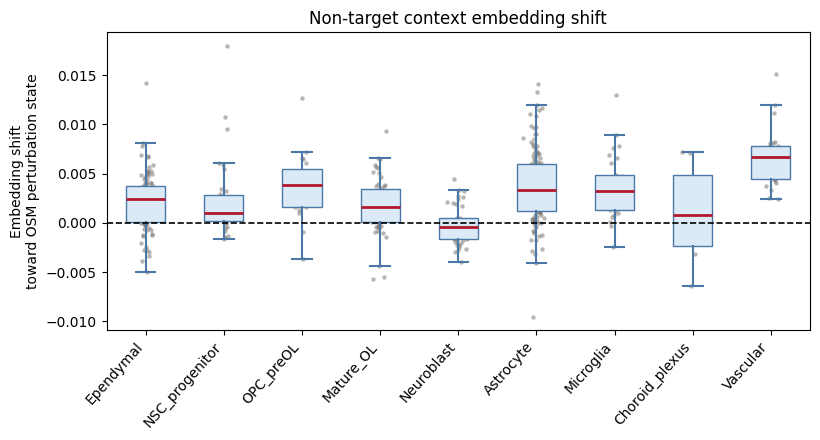

In [14]:
fig, ax = plt.subplots(figsize=(8.3, 4.5))
draw_o_boxplot(ax, niche_df, "Non-target context embedding shift")
fig.tight_layout()
save_panel(fig, "Fig5_M_context_embedding_shift")

## 5. Compare pooled 100-HVG gene responses
Real effects are mean log1p measured expression in OSMInf3 minus BSAInf4. Virtual effects are mean log1p decoder output after OE minus before OE in the same direct or context cells. Each of the three effect vectors is divided by its own RMS before asinh transformation; this compares direction and distribution shape.

In [15]:
from scipy.stats import gaussian_kde
raw = adata_fov_willis
baseline = adata_ori
virtual_input = perturbed_adata_final
virtual = adata_perturb_final
CONTROL_DETECTION_MIN = .05

In [16]:
def dense_array(values):
    return values.toarray() if sp.issparse(values) else np.asarray(values)
raw_x = dense_array(raw.X).astype(float)
virtual_input_x = dense_array(virtual_input.X).astype(float)
baseline_xpred = dense_array(baseline.obsm['X_pred']).astype(float)
virtual_xpred = dense_array(virtual.obsm['X_pred']).astype(float)
gene_symbols = raw.var['gene_symbol'].astype(str).to_numpy()
target_hits = np.flatnonzero(np.char.lower(gene_symbols.astype(str)) == TARGET_SYMBOL.lower())
target_gene_idx = int(target_hits[0])
condition = raw.obs['condition'].astype(str)
control_mask = condition.eq('control').to_numpy()
real_mask = condition.eq('real_perturb').to_numpy()
oe_mask = virtual_input_x[:, target_gene_idx] > raw_x[:, target_gene_idx] + 1e-08
control_detection = (raw_x[control_mask] > 0).mean(axis=0)
eligible_gene_mask = control_detection >= CONTROL_DETECTION_MIN
eligible_gene_mask[target_gene_idx] = False
control_total = raw_x[control_mask].sum(axis=1)
positive_total = control_total[control_total > 0]
normalization_scale = float(np.median(positive_total))
control_norm = np.log1p(raw_x[control_mask] / np.maximum(control_total[:, None], 1.0) * normalization_scale)
control_variance = control_norm.var(axis=0, ddof=1)
hvg_order = np.argsort(-control_variance)
hvg_order = hvg_order[eligible_gene_mask[hvg_order]]
hvg_rank = np.full(raw.n_vars, np.nan)
hvg_rank[hvg_order] = np.arange(1, len(hvg_order) + 1)

def kde_overlap(real_values, virtual_values):
    pooled = np.concatenate([real_values, virtual_values])
    span = float(pooled.max() - pooled.min())
    padding = max(0.25, 0.12 * span)
    grid = np.linspace(pooled.min() - padding, pooled.max() + padding, 1024)
    real_density = gaussian_kde(real_values)(grid)
    virtual_density = gaussian_kde(virtual_values)(grid)
    integrate = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
    real_density /= integrate(real_density, grid)
    virtual_density /= integrate(virtual_density, grid)
    return float(integrate(np.minimum(real_density, virtual_density), grid))

In [17]:
THREEWAY_NICHE_RADIUS_UM = 150
THREEWAY_EFFECT_EPS = 1e-08
THREEWAY_COLORS = {'real': '#C44E52', 'direct': '#2F6FA5', 'niche': '#2A9D8F'}
THREEWAY_LABELS = {'real': 'real OSMInf', 'direct': 'target virtual', 'niche': 'niche virtual'}

def mean_log1p_rows(matrix, mask):
    values = matrix[np.asarray(mask, dtype=bool)]
    if values.shape[0] == 0:
        raise ValueError('Cannot average an empty cell set')
    return np.log1p(np.clip(values, 0, None)).mean(axis=0)

def rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(np.square(values))))

def threeway_normalize(real_values, direct_values, niche_values, mode):
    arrays = {'real': np.asarray(real_values, dtype=float), 'direct': np.asarray(direct_values, dtype=float), 'niche': np.asarray(niche_values, dtype=float)}
    if mode != 'source_specific_rms':
        raise ValueError(f'Unknown RMS mode: {mode}')
    scales = {source: rms(values) for (source, values) in arrays.items()}
    normalized = {source: np.arcsinh(values / max(scales[source], 1e-12)) for (source, values) in arrays.items()}
    return (normalized, scales)

def finite_pair_metrics(reference, candidate):
    reference = np.asarray(reference, dtype=float)
    candidate = np.asarray(candidate, dtype=float)
    valid = np.isfinite(reference) & np.isfinite(candidate) & (np.abs(reference) > THREEWAY_EFFECT_EPS) & (np.abs(candidate) > THREEWAY_EFFECT_EPS)
    x = reference[valid]
    y = candidate[valid]
    if len(x) < 3:
        return {'n_evaluable': int(len(x)), 'sign_agreement': np.nan, 'density_overlap': np.nan, 'pearson': np.nan, 'spearman': np.nan}
    return {'n_evaluable': int(len(x)), 'sign_agreement': float((np.sign(x) == np.sign(y)).mean()), 'density_overlap': kde_overlap(x, y), 'pearson': float(pd.Series(x).corr(pd.Series(y), method='pearson')), 'spearman': float(pd.Series(x).corr(pd.Series(y), method='spearman'))}
control_non_oe_mask = control_mask & ~oe_mask
niche_mask = np.zeros(raw.n_obs, dtype=bool)
slice_values = raw.obs['slice'].astype(str).to_numpy() if 'slice' in raw.obs.columns else np.repeat('all', raw.n_obs)
spatial_xy = raw.obs[['x_centroid', 'y_centroid']].to_numpy(dtype=float)
for slice_name in np.unique(slice_values[oe_mask]):
    centers = np.flatnonzero(oe_mask & (slice_values == slice_name))
    candidates = np.flatnonzero(control_non_oe_mask & (slice_values == slice_name))
    if len(centers) == 0 or len(candidates) == 0:
        continue
    candidate_tree = cKDTree(spatial_xy[candidates])
    neighbor_lists = candidate_tree.query_ball_point(spatial_xy[centers], r=THREEWAY_NICHE_RADIUS_UM)
    if len(neighbor_lists) > 0:
        local_indices = sorted({idx for group in neighbor_lists for idx in group})
        if local_indices:
            niche_mask[candidates[np.asarray(local_indices, dtype=int)]] = True
threeway_cell_manifest = pd.DataFrame([{'cell_set': 'control_all', 'n_cells': int(control_mask.sum()), 'definition': 'all raw BSAInf ROI cells'}, {'cell_set': 'real_all', 'n_cells': int(real_mask.sum()), 'definition': 'all raw OSMInf ROI cells'}, {'cell_set': 'target_virtual', 'n_cells': int(oe_mask.sum()), 'definition': 'directly edited OSMR-OE BSAInf cells'}, {'cell_set': 'niche_virtual', 'n_cells': int(niche_mask.sum()), 'definition': f'non-OE BSAInf cells within {THREEWAY_NICHE_RADIUS_UM} um of an OE cell'}])
threeway_cell_manifest['niche_coverage_of_non_oe_control'] = float(niche_mask.sum() / max(control_non_oe_mask.sum(), 1))
pooled_raw = pd.DataFrame({'gene_idx': np.arange(raw.n_vars, dtype=int), 'gene': gene_symbols, 'real_delta': mean_log1p_rows(raw_x, real_mask) - mean_log1p_rows(raw_x, control_mask), 'direct_delta': mean_log1p_rows(virtual_xpred, oe_mask) - mean_log1p_rows(baseline_xpred, oe_mask), 'niche_delta': mean_log1p_rows(virtual_xpred, niche_mask) - mean_log1p_rows(baseline_xpred, niche_mask)})
pooled_raw = pooled_raw.loc[pooled_raw['gene_idx'].map(pd.Series(eligible_gene_mask, index=np.arange(raw.n_vars)))].copy()

,comparison,n_evaluable,sign_agreement,density_overlap,pearson,spearman
0,Direct,100,0.79,0.809430,0.453216,0.390219
1,Context,100,0.52,0.746473,0.168174,0.035044


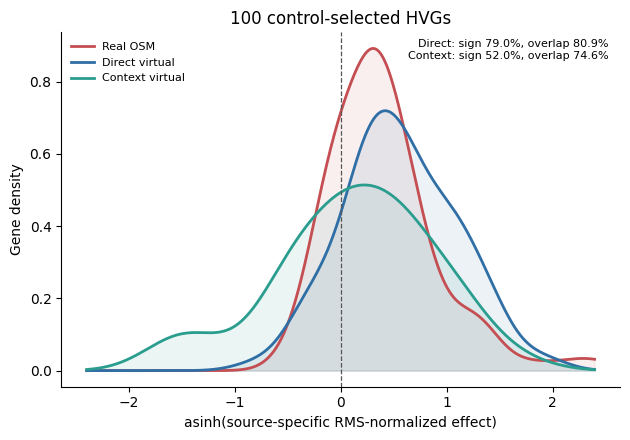

In [18]:
gene_indices = hvg_order[:100]
effects = pooled_raw[pooled_raw["gene_idx"].isin(gene_indices)].sort_values("gene_idx").copy()
normalized, scales = threeway_normalize(effects["real_delta"], effects["direct_delta"], effects["niche_delta"], "source_specific_rms")
for source, values in normalized.items():
    effects[source + "_effect"] = values
direct_metrics = finite_pair_metrics(effects["real_effect"], effects["direct_effect"])
niche_metrics = finite_pair_metrics(effects["real_effect"], effects["niche_effect"])
summary = pd.DataFrame([{"comparison": label, **values} for label, values in [("Direct", direct_metrics), ("Context", niche_metrics)]])
effects.to_csv(OUT_DIR / "Fig5_N_gene_effects.csv", index=False)
summary.to_csv(OUT_DIR / "Fig5_N_concordance.csv", index=False)
display(summary)
fig, ax = plt.subplots(figsize=(6.4, 4.5))
limit = max(1., float(np.quantile(np.abs(np.concatenate(list(normalized.values()))), .995)) * 1.15)
grid = np.linspace(-limit, limit, 900)
for source, label in [("real", "Real OSM"), ("direct", "Direct virtual"), ("niche", "Context virtual")]:
    density = gaussian_kde(normalized[source])(grid)
    integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    density /= integrate(density, grid)
    ax.plot(grid, density, lw=2, color=THREEWAY_COLORS[source], label=label)
    ax.fill_between(grid, 0, density, color=THREEWAY_COLORS[source], alpha=.09)
ax.axvline(0, color="#555555", ls="--", lw=.9)
ax.set(xlabel="asinh(source-specific RMS-normalized effect)", ylabel="Gene density",
       title=f"{len(effects)} control-selected HVGs")
annotation = chr(10).join(f"{label}: sign {values['sign_agreement']:.1%}, overlap {values['density_overlap']:.1%}" for label, values in [("Direct", direct_metrics), ("Context", niche_metrics)])
ax.text(.98, .98, annotation, transform=ax.transAxes, ha="right", va="top", fontsize=8)
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
save_panel(fig, "Fig5_N_gene_response_density")
adata_panel.file.close()